<a href="https://colab.research.google.com/github/Sunwi01/week6-lab/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Lab: Decision Tree from Scratch in Numpy -> Sklearn

## Objective
Implement a **Decision Tree** classifier using **NumPy** and **Sklearn** with two impurity measures:
- **Gini Impurity**
- **Entropy (Information Gain)**

We use a simple **student pass/fail** classification problem with **two features**:
1. **Study hours per week**
2. **Attendance percentage**

In [1]:
# ========== STEP 0: Imports ==========
# Run this cell first. We need NumPy, Matplotlib, and Counter for the tree.
#part I
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

#part II
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree
from sklearn.tree import plot_tree

---
## 1. Student Pass/Fail Dataset

Two features:
- **X1**: Study hours per week (e.g., 0–20)
- **X2**: Attendance % (e.g., 0–100)

**Target**: 1 = Pass, 0 = Fail

Simple rule: students who study more *and* attend more tend to pass.

In [2]:
# Step 1.1: Set random seed and sample size
np.random.seed(42)
n_samples = 80

# Step 1.2: Create PASS students (high study hours AND high attendance)
study_pass = np.random.uniform(12, 20, size=(n_samples // 2, 1))
attend_pass = np.random.uniform(70, 100, size=(n_samples // 2, 1))
X_pass = np.hstack([study_pass, attend_pass])
y_pass = np.ones(n_samples // 2, dtype=int)

# Step 1.3: Create FAIL students (low study OR low attendance)
study_fail1 = np.random.uniform(0, 8, size=(n_samples // 4, 1))
attend_fail1 = np.random.uniform(0, 100, size=(n_samples // 4, 1))
study_fail2 = np.random.uniform(0, 20, size=(n_samples // 4, 1))
attend_fail2 = np.random.uniform(0, 65, size=(n_samples // 4, 1))
X_fail = np.vstack([
    np.hstack([study_fail1, attend_fail1]),
    np.hstack([study_fail2, attend_fail2])
])
y_fail = np.zeros(X_fail.shape[0], dtype=int)

# Step 1.4: Combine and shuffle
X = np.vstack([X_pass, X_fail])
y = np.concatenate([y_pass, y_fail])
shuffle_idx = np.random.permutation(len(y))
X, y = X[shuffle_idx], y[shuffle_idx]

# Step 1.5: Inspect
print("Dataset shape:", X.shape)
print("Features: [Study hours, Attendance %]")
print("Target: 1=Pass, 0=Fail")
print("\nFirst 10 samples:")
print(np.column_stack([X[:10], y[:10]]))

Dataset shape: (80, 2)
Features: [Study hours, Attendance %]
Target: 1=Pass, 0=Fail

First 10 samples:
[[19.5910843  94.46384285  1.        ]
 [17.66458062 75.54563367  1.        ]
 [ 2.48785857 90.75664739  0.        ]
 [18.65954113 98.18496825  1.        ]
 [16.89482316 81.66031869  1.        ]
 [13.59739026 74.22772675  1.        ]
 [ 3.42032815 18.65700589  0.        ]
 [ 0.95675397 28.97514529  0.        ]
 [17.921826   16.36584923  0.        ]
 [ 2.6471842  31.43559811  0.        ]]


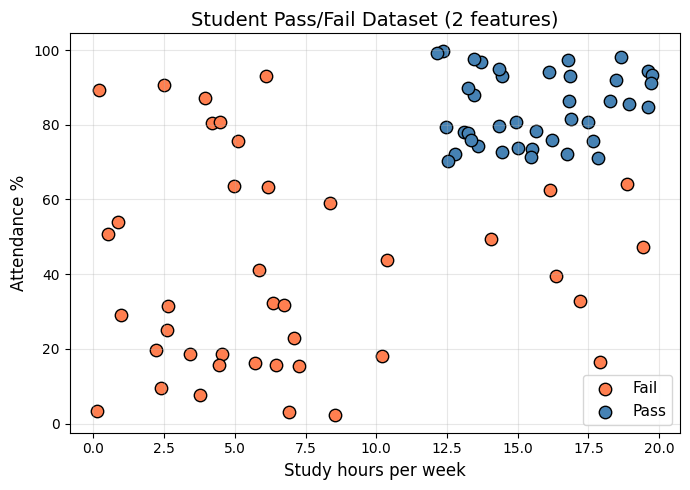

In [3]:
# Scatter: X-axis = Study hours, Y-axis = Attendance. Pass vs Fail in different colors.
plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='coral', edgecolors='k', label='Fail', s=80)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='steelblue', edgecolors='k', label='Pass', s=80)
plt.xlabel('Study hours per week', fontsize=12)
plt.ylabel('Attendance %', fontsize=12)
plt.title('Student Pass/Fail Dataset (2 features)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Impurity Measures: Gini vs Entropy

**Gini Impurity** (for a node with class proportions \(p_k\)):
$$Gini = 1 - \sum_{k} p_k^2$$

**Entropy**:
$$H = -\sum_{k} p_k \log_2(p_k)$$

We use these to choose the best **split** (feature + threshold) at each node.

In [4]:
# Gini: 1 - sum(p_k^2). Entropy: -sum(p_k * log2(p_k)). We use these to pick the best split.

def gini_impurity(y):
    """Gini impurity for labels y (binary or multi-class)."""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs = counts / len(y)
    return 1.0 - np.sum(probs ** 2)


def entropy(y):
    """Entropy for labels y. Use log2 and avoid log(0)."""
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs = counts / len(y)
    probs = probs[probs > 0]  # avoid log(0)
    return -np.sum(probs * np.log2(probs))


# Quick check: mixed labels have positive impurity; pure nodes would give 0.
print("Gini for full labels:", gini_impurity(y))
print("Entropy for full labels:", entropy(y))

Gini for full labels: 0.5
Entropy for full labels: 1.0


---
## 3. Decision Tree Class (NumPy only)

- **criterion**: `'gini'` or `'entropy'`
- **max_depth**: limit tree depth
- Each node stores: feature index, threshold, left/right children, and leaf prediction.

In [5]:
# Idea: At each node, find the best "question" (which feature? what threshold?) that best separates
#       the classes. Split data into left (yes) and right (no), then repeat until we stop (leaf).
#       A leaf just predicts the majority class of the samples that reached it.

class DecisionTreeClassifier:
    """
    Simple Decision Tree for classification (NumPy only).
    - criterion: 'gini' or 'entropy' (how we measure "how mixed" a node is).
    - max_depth: how many levels of questions we allow (stops overfitting).
    """

    def __init__(self, criterion='gini', max_depth=5):
        self.criterion = criterion
        self.max_depth = max_depth
        # Pick the impurity function once (Gini or Entropy)
        self.impurity_fn = gini_impurity if criterion == 'gini' else entropy
        self.tree = None   # Will hold the root of the tree after fit()

    # -------------------------------------------------------------------------
    # Step 1: Find the best split (feature + threshold) for this node
    # -------------------------------------------------------------------------
    # We try every feature and, for each feature, every "midpoint" between two
    # consecutive values as threshold. The best split is the one that reduces
    # impurity the most (largest "information gain").
    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        if n_samples <= 1:
            return None, None   # Too few samples to split

        impurity_before = self.impurity_fn(y)
        best_gain = -1
        best_feature = None
        best_threshold = None

        # Try each feature in turn
        for feat in range(n_features):
            # Get sorted unique values for this feature; thresholds = midpoints between them
            values = np.unique(X[:, feat])
            for i in range(len(values) - 1):
                thresh = (values[i] + values[i + 1]) / 2
                # Split: left = "feature <= threshold", right = "feature > threshold"
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                y_left = y[left_mask]
                y_right = y[right_mask]
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                # Weighted average impurity after split (lower is better)
                n_left, n_right = len(y_left), len(y_right)
                impurity_left = self.impurity_fn(y_left)
                impurity_right = self.impurity_fn(y_right)
                impurity_after = (n_left * impurity_left + n_right * impurity_right) / n_samples
                gain = impurity_before - impurity_after
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feat
                    best_threshold = thresh

        return best_feature, best_threshold

    # -------------------------------------------------------------------------
    # Step 2: Build the tree recursively
    # -------------------------------------------------------------------------
    # - If we hit max depth, or all labels are the same, or too few samples → make a leaf (predict majority class).
    # - Otherwise find best split, split the data, and build left and right subtrees.
    def _build_tree(self, X, y, depth):
        # Stop conditions: make a leaf and predict the most common class here
        all_same_class = len(np.unique(y)) == 1
        too_few_samples = len(y) < 2
        if depth >= self.max_depth or all_same_class or too_few_samples:
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': majority_class}

        feat, thresh = self._find_best_split(X, y)
        if feat is None:
            majority_class = Counter(y).most_common(1)[0][0]
            return {'leaf': True, 'value': majority_class}

        # Split data and build left and right subtrees
        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask
        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': feat,
            'threshold': thresh,
            'left': left_tree,
            'right': right_tree,
        }

    # -------------------------------------------------------------------------
    # Step 3: Fit and predict
    # -------------------------------------------------------------------------
    def fit(self, X, y):
        """Train the tree on data X (features) and y (labels)."""
        X = np.asarray(X)
        y = np.asarray(y)
        self.tree = self._build_tree(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        """Predict the class for a single sample x by walking down the tree."""
        if node['leaf']:
            return node['value']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        """Predict class for each row in X."""
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree) for x in X])

---
## 4. Train with Gini and Entropy & Decision Boundary

We train two trees (Gini and Entropy) and plot their **decision boundaries** on the same student dataset.

In [6]:
# Grid over (x,y), predict each point, then contourf + scatter data.
def plot_decision_boundary(model, X, y, title, ax):
    """Plot data points and decision boundary for 2D features."""
    h = 0.25
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=ListedColormap(['#ffb3a3', '#a3c4e8']))
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='coral', edgecolors='k', label='Fail', s=60)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='steelblue', edgecolors='k', label='Pass', s=60)
    ax.set_xlabel('Study hours')
    ax.set_ylabel('Attendance %')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

In [7]:
# Step 6.1: Create models with criterion='gini' and 'entropy', max_depth=4
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=4)
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4)
# Step 6.2: Fit on X, y
tree_gini.fit(X, y)
tree_entropy.fit(X, y)
# Step 6.3: Compute training accuracy
acc_gini = np.mean(tree_gini.predict(X) == y)
acc_entropy = np.mean(tree_entropy.predict(X) == y)
print("Training accuracy (Gini):   {:.2%}".format(acc_gini))
print("Training accuracy (Entropy): {:.2%}".format(acc_entropy))

Training accuracy (Gini):   100.00%
Training accuracy (Entropy): 100.00%


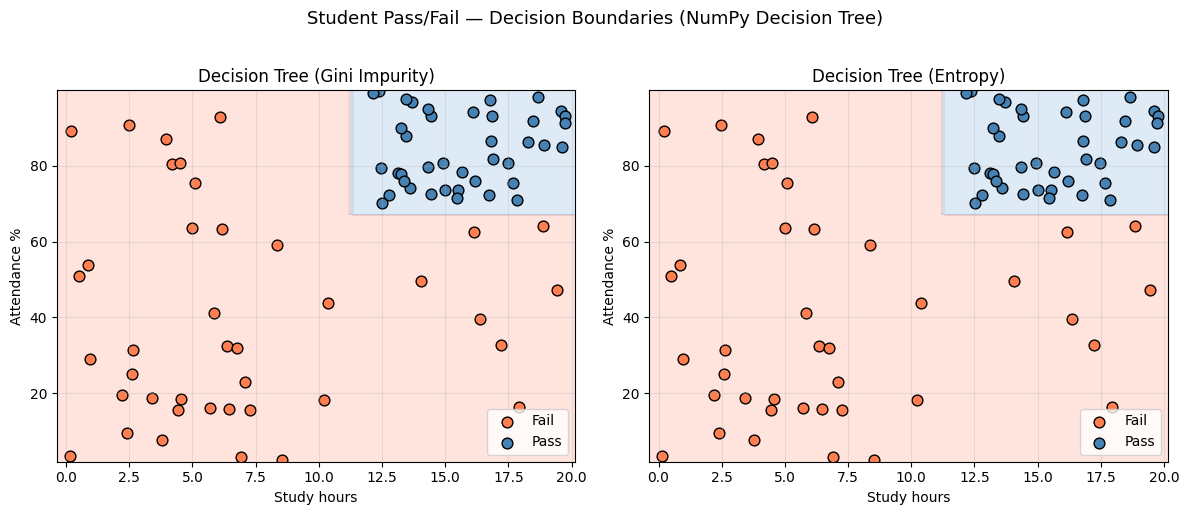

In [8]:
#Plot decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(tree_gini, X, y, 'Decision Tree (Gini Impurity)', axes[0])
plot_decision_boundary(tree_entropy, X, y, 'Decision Tree (Entropy)', axes[1])
plt.suptitle('Student Pass/Fail — Decision Boundaries (NumPy Decision Tree)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Tree Structure Visualization (Text)

Print the learned tree structure: each node shows **feature**, **threshold**, and leaf **class**.

In [10]:
# feat_names: use 2 names for Part A; for 3 features (Part B) pass ['Study hours','Attendance %','Assignment %'].
def print_tree(node, depth=0, prefix='', feat_names=None):
    if feat_names is None:
        feat_names = ['Study hours', 'Attendance %']
    if node['leaf']:
        label = 'Pass' if node['value'] == 1 else 'Fail'
        print(prefix + f'→ Predict: {label}')
        return
    name = feat_names[node['feature']]
    print(prefix + f'{name} <= {node["threshold"]:.2f}?')
    print_tree(node['left'], depth + 1, prefix + '  Yes: ', feat_names)
    print_tree(node['right'], depth + 1, prefix + '  No:  ', feat_names)


print("=== Tree (Gini) ===\n")
print_tree(tree_gini.tree)
print("\n=== Tree (Entropy) ===\n")
print_tree(tree_entropy.tree)

=== Tree (Gini) ===

Study hours <= 11.27?
  Yes: → Predict: Fail
  No:  Attendance % <= 67.12?
  No:    Yes: → Predict: Fail
  No:    No:  → Predict: Pass

=== Tree (Entropy) ===

Study hours <= 11.27?
  Yes: → Predict: Fail
  No:  Attendance % <= 67.12?
  No:    Yes: → Predict: Fail
  No:    No:  → Predict: Pass


---
## 6. Predict New Students

Example: predict pass/fail for a few new students (study hours, attendance).

In [9]:
# New students: [Study hours, Attendance %]
new_students = np.array([
    [18, 85],   # High study, high attendance → expect Pass
    [5, 50],    # Low both → expect Fail
    [15, 90],   # High both → expect Pass
    [10, 55],   # Medium/Mixed
])
pred_gini = tree_gini.predict(new_students)
pred_entropy = tree_entropy.predict(new_students)
labels = ['Pass' if p == 1 else 'Fail' for p in pred_gini]
print("New students [Study hrs, Attendance %] → Prediction (Gini / Entropy)")
for i, row in enumerate(new_students):
    e_label = 'Pass' if pred_entropy[i] == 1 else 'Fail'
    print(f"  {row} → {labels[i]} / {e_label}")

New students [Study hrs, Attendance %] → Prediction (Gini / Entropy)
  [18 85] → Pass / Pass
  [ 5 50] → Fail / Fail
  [15 90] → Pass / Pass
  [10 55] → Fail / Fail


---
# Same Example with scikit-learn (Study hours & Attendance)

We use the **same 2-feature dataset** (study hours, attendance) and **same number of students** as in Part A, but train with **sklearn's DecisionTreeClassifier**. Compare Gini vs Entropy and visualize the tree.

In [11]:
# Step 1: Train sklearn DecisionTree with Gini and Entropy (same data X, y from Part A)
skl_gini = SklearnDecisionTree(criterion='gini', max_depth=4, random_state=42)
skl_entropy = SklearnDecisionTree(criterion='entropy', max_depth=4, random_state=42)
skl_gini.fit(X, y)
skl_entropy.fit(X, y)

# Step 2: Training accuracy
print("Training accuracy (sklearn Gini):   {:.2%}".format(skl_gini.score(X, y)))
print("Training accuracy (sklearn Entropy): {:.2%}".format(skl_entropy.score(X, y)))

# Step 3: Predict same new_students as in Part A
new_students = np.array([[18, 85], [5, 50], [15, 90], [10, 55]])
pred_skl_g = skl_gini.predict(new_students)
pred_skl_e = skl_entropy.predict(new_students)
print("\nNew students [Study hrs, Attendance %] → sklearn (Gini / Entropy):")
for i, row in enumerate(new_students):
    print(f"  {row} → {'Pass' if pred_skl_g[i]==1 else 'Fail'} / {'Pass' if pred_skl_e[i]==1 else 'Fail'}")

Training accuracy (sklearn Gini):   100.00%
Training accuracy (sklearn Entropy): 100.00%

New students [Study hrs, Attendance %] → sklearn (Gini / Entropy):
  [18 85] → Pass / Pass
  [ 5 50] → Fail / Fail
  [15 90] → Pass / Pass
  [10 55] → Fail / Fail


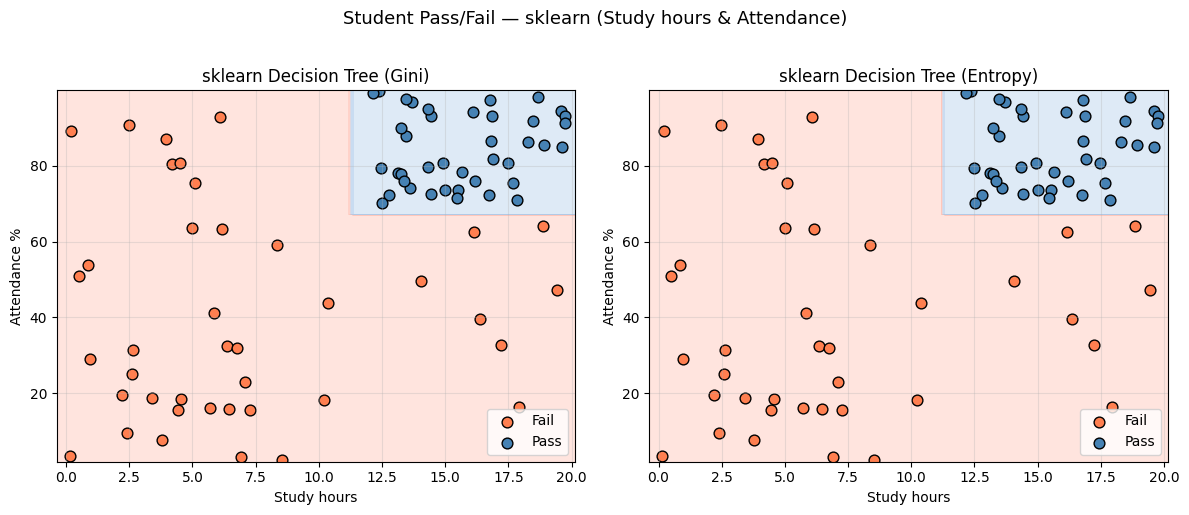

In [12]:
# Decision boundary (sklearn) — same plot_decision_boundary helper works (model has .predict)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(skl_gini, X, y, 'sklearn Decision Tree (Gini)', axes[0])
plot_decision_boundary(skl_entropy, X, y, 'sklearn Decision Tree (Entropy)', axes[1])
plt.suptitle('Student Pass/Fail — sklearn (Study hours & Attendance)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

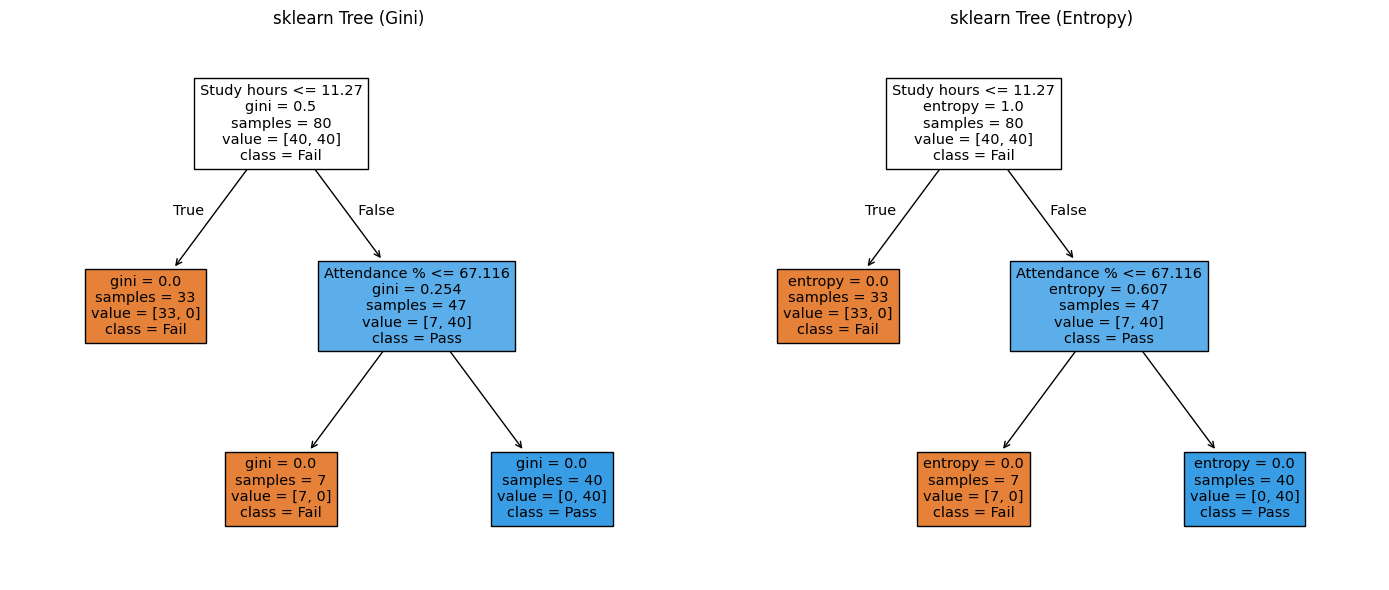

In [13]:
# Visualize sklearn tree (feature names = Study hours, Attendance %)
feat_names_2 = ['Study hours', 'Attendance %']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_tree(skl_gini, feature_names=feat_names_2, class_names=['Fail', 'Pass'], filled=True, ax=axes[0])
axes[0].set_title('sklearn Tree (Gini)')
plot_tree(skl_entropy, feature_names=feat_names_2, class_names=['Fail', 'Pass'], filled=True, ax=axes[1])
axes[1].set_title('sklearn Tree (Entropy)')
plt.tight_layout()
plt.show()

---
# Student Exercises: Pass/Fail (3 Features) + Iris

**Exercises:** 3-feature student pass/fail (Part A & B) and **Iris dataset** (Part C).

| Part | Marks | Task |
|------|-------|------|
| **Part A** | **50%** | Implement decision tree using **NumPy** (as in the example above): dataset generation, visualization, and full tree implementation (3 features). |
| **Part B** | **30%** | Solve the same 3-feature problem using the **scikit-learn** library. |
| **Part C** | **20%** | Load the **Iris** dataset; train a decision tree (NumPy or sklearn), visualize and report accuracy. |

Use the commented hints in each code block to complete the exercises. Run the main lab (Steps 0–8 and the DecisionTreeClassifier class) before attempting Part A.

---
## Exercise 1 — Part A (50%): Decision Tree with NumPy (3 Features)

**Goal:** Generate a 3-feature student pass/fail dataset, visualize it, and implement a decision tree using **NumPy only** (follow the example in Section 3).

**Features:**  
1. Study hours per week (0–20)  
2. Attendance % (0–100)  
3. Assignment score % (0–100)  

**Target:** 1 = Pass, 0 = Fail (e.g. pass when all three are high).

### Part A — Step 1: Dataset generation



In [14]:
# ==========   Dataset generation (3 features)  ==========
np.random.seed(13)
n_ex = 100  # total number of samples

study_pass_ex = np.random.uniform(12, 20, (n_ex // 2, 1))
attend_pass_ex = np.random.uniform(70, 100, (n_ex // 2, 1))
assign_pass_ex = np.random.uniform(65, 100, (n_ex // 2, 1))
X_ex_pass = np.hstack([study_pass_ex, attend_pass_ex, assign_pass_ex])
y_ex_pass = np.ones(n_ex // 2, dtype=int)

study_fail_ex = np.random.uniform(0, 10, (n_ex // 2, 1))
attend_fail_ex = np.random.uniform(0, 70, (n_ex // 2, 1))
assign_fail_ex = np.random.uniform(0, 65, (n_ex // 2, 1))
X_ex_fail = np.hstack([study_fail_ex, attend_fail_ex, assign_fail_ex])
y_ex_fail = np.zeros(n_ex // 2, dtype=int)

X_ex = np.vstack([X_ex_pass, X_ex_fail])
y_ex = np.concatenate([y_ex_pass, y_ex_fail])

idx_ex = np.random.permutation(len(y_ex))
X_ex, y_ex = X_ex[idx_ex], y_ex[idx_ex]

print("Shape X_ex:", X_ex.shape, "| y_ex:", y_ex.shape)
print("Features: [Study hours, Attendance %, Assignment %] | Target: 1=Pass, 0=Fail")
print("First 5 rows (X_ex, y_ex):\n", np.column_stack([X_ex[:5], y_ex[:5]]))

Shape X_ex: (100, 3) | y_ex: (100,)
Features: [Study hours, Attendance %, Assignment %] | Target: 1=Pass, 0=Fail
First 5 rows (X_ex, y_ex):
 [[ 0.52866202  4.99975936 18.32491195  0.        ]
 [16.83631063 78.08154086 72.92761632  1.        ]
 [14.21597085 95.33675598 67.48757294  1.        ]
 [ 8.44414256 10.04643839 27.88180068  0.        ]
 [12.5206763  96.17295587 94.02611931  1.        ]]


### Part A — Step 2: Visualize the 3-feature data

Plot of **pairwise** 2D views (Study vs Attendance, Study vs Assignment, Attendance vs Assignment)

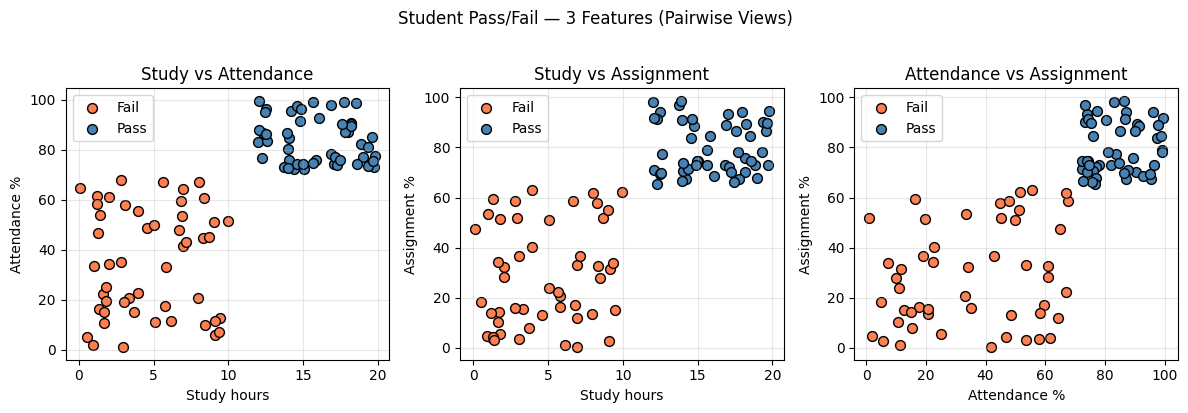

In [15]:
# ========== Part A — Visualization (pairwise 2D scatter) ==========
feat_labels_ex = ['Study hours', 'Attendance %', 'Assignment %']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Feature 0 vs 1 (Study vs Attendance)
axes[0].scatter(X_ex[y_ex == 0, 0], X_ex[y_ex == 0, 1], c='coral', edgecolors='k', label='Fail', s=50)
axes[0].scatter(X_ex[y_ex == 1, 0], X_ex[y_ex == 1, 1], c='steelblue', edgecolors='k', label='Pass', s=50)
axes[0].set_xlabel(feat_labels_ex[0]); axes[0].set_ylabel(feat_labels_ex[1]); axes[0].set_title('Study vs Attendance'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: Feature 0 vs 2 (Study vs Assignment)
axes[1].scatter(X_ex[y_ex == 0, 0], X_ex[y_ex == 0, 2], c='coral', edgecolors='k', label='Fail', s=50)
axes[1].scatter(X_ex[y_ex == 1, 0], X_ex[y_ex == 1, 2], c='steelblue', edgecolors='k', label='Pass', s=50)
axes[1].set_xlabel(feat_labels_ex[0]); axes[1].set_ylabel(feat_labels_ex[2]); axes[1].set_title('Study vs Assignment'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Plot 3: Feature 1 vs 2 (Attendance vs Assignment)
axes[2].scatter(X_ex[y_ex == 0, 1], X_ex[y_ex == 0, 2], c='coral', edgecolors='k', label='Fail', s=50)
axes[2].scatter(X_ex[y_ex == 1, 1], X_ex[y_ex == 1, 2], c='steelblue', edgecolors='k', label='Pass', s=50)
axes[2].set_xlabel(feat_labels_ex[1]); axes[2].set_ylabel(feat_labels_ex[2]); axes[2].set_title('Attendance vs Assignment'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Student Pass/Fail — 3 Features (Pairwise Views)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Part A — Step 3: Implement and train the Decision Tree (NumPy)

Use the **same** `DecisionTreeClassifier` class and impurity functions (`gini_impurity`, `entropy`) from **Section 3** in this notebook. Train one tree with `criterion='gini'` and optionally one with `criterion='entropy'` on `(X_ex, y_ex)`. Compute and print training accuracy.

In [16]:
# ========== Part A — Train NumPy Decision Tree on (X_ex, y_ex) — use hints ==========
# HINT 1: Create DecisionTreeClassifier(criterion='gini', max_depth=5) — same class as in Section 3


# Gini-based tree
tree_ex = DecisionTreeClassifier(criterion='gini', max_depth=5)

tree_ex.fit(X_ex, y_ex)

pred_ex = tree_ex.predict(X_ex)

acc_ex = np.mean(pred_ex == y_ex)

print(f"Training accuracy on gini based tree: {acc_ex:.4f}")


# Entropy-based tree
tree_ex_ent = DecisionTreeClassifier(criterion='entropy', max_depth=5)

tree_ex_ent.fit(X_ex, y_ex)

pred_ex_ent = tree_ex_ent.predict(X_ex)

acc_ex_ent = np.mean(pred_ex_ent == y_ex)

print(f"Training accuracy on entropy based tree: {acc_ex_ent:.4f}")

# Training accuracy on entropy based tree

Training accuracy on gini based tree: 1.0000
Training accuracy on entropy based tree: 1.0000


### Part A — Step 4: Decision boundary (pairwise) and prediction

For 3 features we plot **pairwise** decision boundaries by fixing the third feature at its **median**.

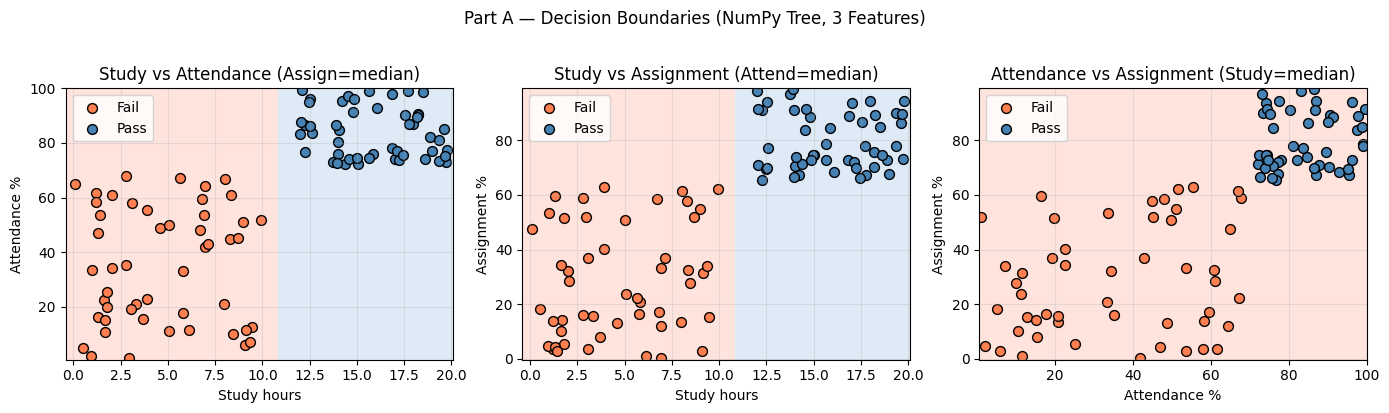

New students [Study, Attend, Assign] → Prediction:
  [18 88 90] → Pass
  [ 5 45 40] → Fail
  [14 82 75] → Pass


In [17]:
# ========== Part A — Pairwise decision boundary and predict — use hints ==========
# Median of each feature: med_ex = np.median(X_ex, axis=0)
med_ex = np.median(X_ex, axis=0)

# For each pair (fi, fj), build meshgrid over X_ex[:,fi] and X_ex[:,fj]; third feature index fk = 3-fi-fj, fill with med_ex[fk]
#          Get Z = model.predict(grid_3d), reshape to grid, then contourf; scatter data points with Pass/Fail colors.
def plot_pairwise_ex(model, X, y, fi, fj, ax, title, med, feat_names):
    fk = 3 - fi - fj
    h = 0.5
    x_min, x_max = X[:, fi].min() - 0.5, X[:, fi].max() + 0.5
    y_min, y_max = X[:, fj].min() - 0.5, X[:, fj].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_3d = np.zeros((xx.size, 3))
    grid_3d[:, fi], grid_3d[:, fj], grid_3d[:, fk] = xx.ravel(), yy.ravel(), med[fk]
    Z = model.predict(grid_3d).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=ListedColormap(['#ffb3a3', '#a3c4e8']))
    ax.scatter(X[y == 0, fi], X[y == 0, fj], c='coral', edgecolors='k', label='Fail', s=50)
    ax.scatter(X[y == 1, fi], X[y == 1, fj], c='steelblue', edgecolors='k', label='Pass', s=50)
    ax.set_xlabel(feat_names[fi]); ax.set_ylabel(feat_names[fj]); ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_pairwise_ex(tree_ex, X_ex, y_ex, 0, 1, axes[0], 'Study vs Attendance (Assign=median)', med_ex, feat_labels_ex)
plot_pairwise_ex(tree_ex, X_ex, y_ex, 0, 2, axes[1], 'Study vs Assignment (Attend=median)', med_ex, feat_labels_ex)
plot_pairwise_ex(tree_ex, X_ex, y_ex, 1, 2, axes[2], 'Attendance vs Assignment (Study=median)', med_ex, feat_labels_ex)
plt.suptitle('Part A — Decision Boundaries (NumPy Tree, 3 Features)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# New students [Study hrs, Attendance %, Assignment %] — predict and print
new_ex = np.array([[18, 88, 90], [5, 45, 40], [14, 82, 75]])
pred_ex = tree_ex.predict(new_ex)
print("New students [Study, Attend, Assign] → Prediction:")
for i, row in enumerate(new_ex):
    print(f"  {row} → {'Pass' if pred_ex[i] == 1 else 'Fail'}")

---
## Exercise 2 — Part B (30%): Same Problem with scikit-learn

**Goal:** Solve the **same** 3-feature student pass/fail problem using **scikit-learn** `DecisionTreeClassifier`. Use the same data `X_ex`, `y_ex` from Part A (or regenerate if needed). Train the model, plot pairwise decision boundaries, and predict for new students.

Training accuracy using sklearn Decision Tree: 1.0000


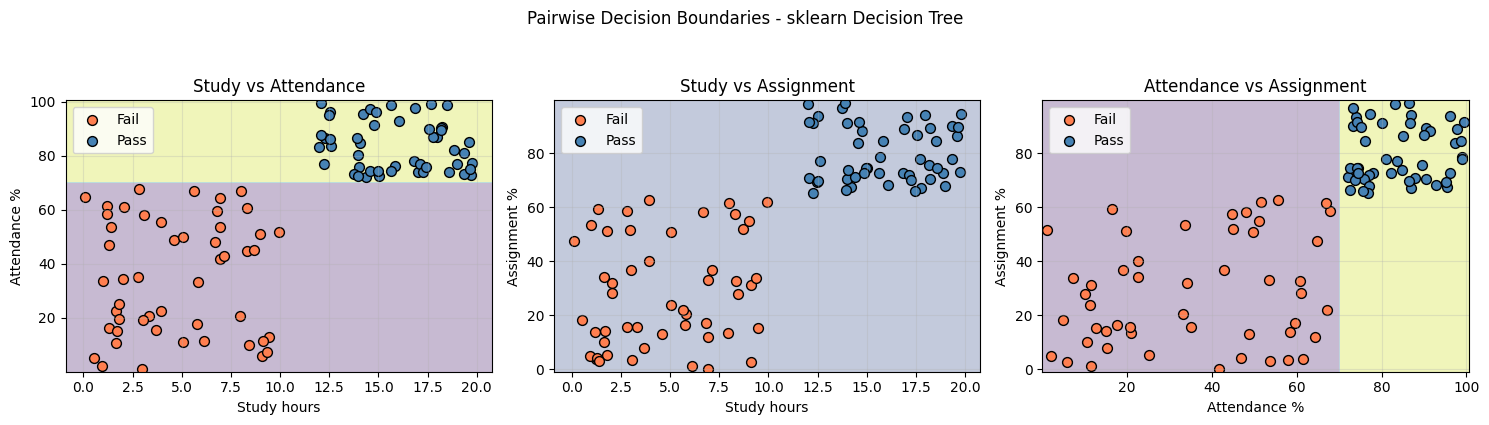

New students [Study, Attend, Assign] → sklearn Prediction:
[18 88 90] → Pass
[ 5 45 40] → Fail
[14 82 75] → Pass


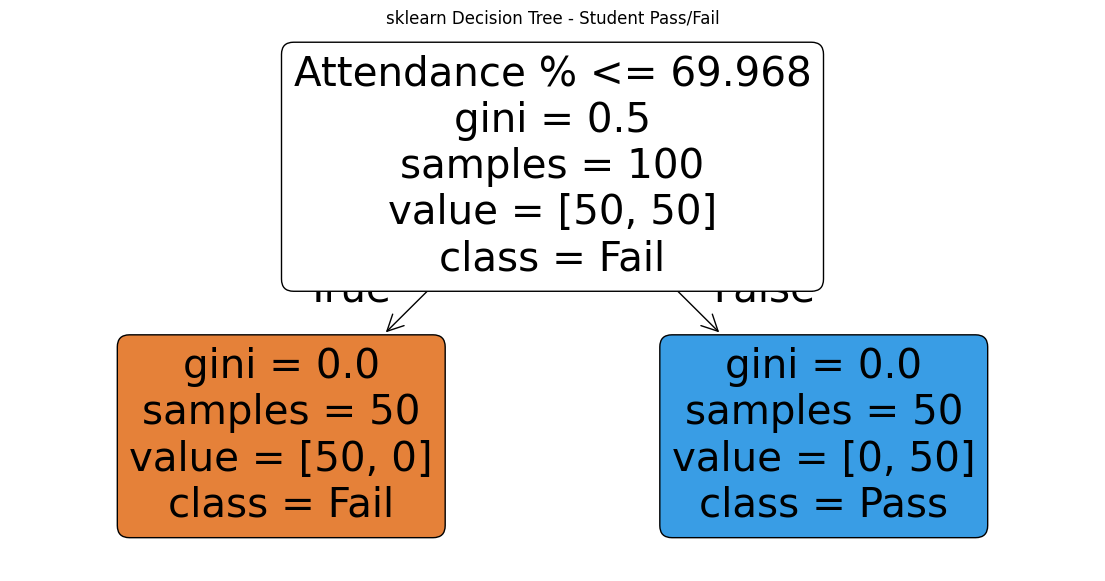

In [21]:
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree
from sklearn.tree import plot_tree
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Train sklearn Decision Tree
# -----------------------------
skl_ex = SklearnDecisionTree(
    criterion="gini",
    max_depth=5,
    random_state=42
)

skl_ex.fit(X_ex, y_ex)

print(f"Training accuracy using sklearn Decision Tree: {skl_ex.score(X_ex, y_ex):.4f}")


# -----------------------------
# 2. Helper for pairwise decision boundary
# -----------------------------
def plot_pairwise_boundary(model, X, y, fi, fj, ax, title, feat_names):
    x_min, x_max = X[:, fi].min() - 1, X[:, fi].max() + 1
    y_min, y_max = X[:, fj].min() - 1, X[:, fj].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Use median values for the third feature
    X_grid = np.tile(np.median(X, axis=0), (xx.ravel().shape[0], 1))
    X_grid[:, fi] = xx.ravel()
    X_grid[:, fj] = yy.ravel()

    Z = model.predict(X_grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)

    ax.scatter(
        X[y == 0, fi],
        X[y == 0, fj],
        c="coral",
        edgecolors="k",
        label="Fail",
        s=50
    )

    ax.scatter(
        X[y == 1, fi],
        X[y == 1, fj],
        c="steelblue",
        edgecolors="k",
        label="Pass",
        s=50
    )

    ax.set_xlabel(feat_names[fi])
    ax.set_ylabel(feat_names[fj])
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


# -----------------------------
# 3. Plot pairwise boundaries
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pairwise_boundary(
    skl_ex, X_ex, y_ex,
    fi=0, fj=1,
    ax=axes[0],
    title="Study vs Attendance",
    feat_names=feat_labels_ex
)

plot_pairwise_boundary(
    skl_ex, X_ex, y_ex,
    fi=0, fj=2,
    ax=axes[1],
    title="Study vs Assignment",
    feat_names=feat_labels_ex
)

plot_pairwise_boundary(
    skl_ex, X_ex, y_ex,
    fi=1, fj=2,
    ax=axes[2],
    title="Attendance vs Assignment",
    feat_names=feat_labels_ex
)

plt.suptitle("Pairwise Decision Boundaries - sklearn Decision Tree", y=1.05)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Predict new students
# -----------------------------
new_ex_skl = np.array([
    [18, 88, 90],
    [5, 45, 40],
    [14, 82, 75]
])

pred_skl_ex = skl_ex.predict(new_ex_skl)

print("New students [Study, Attend, Assign] → sklearn Prediction:")

for student, pred in zip(new_ex_skl, pred_skl_ex):
    result = "Pass" if pred == 1 else "Fail"
    print(f"{student} → {result}")


# -----------------------------
# 5. Optional: plot tree
# -----------------------------
plt.figure(figsize=(14, 7))
plot_tree(
    skl_ex,
    feature_names=feat_labels_ex,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("sklearn Decision Tree - Student Pass/Fail")
plt.show()

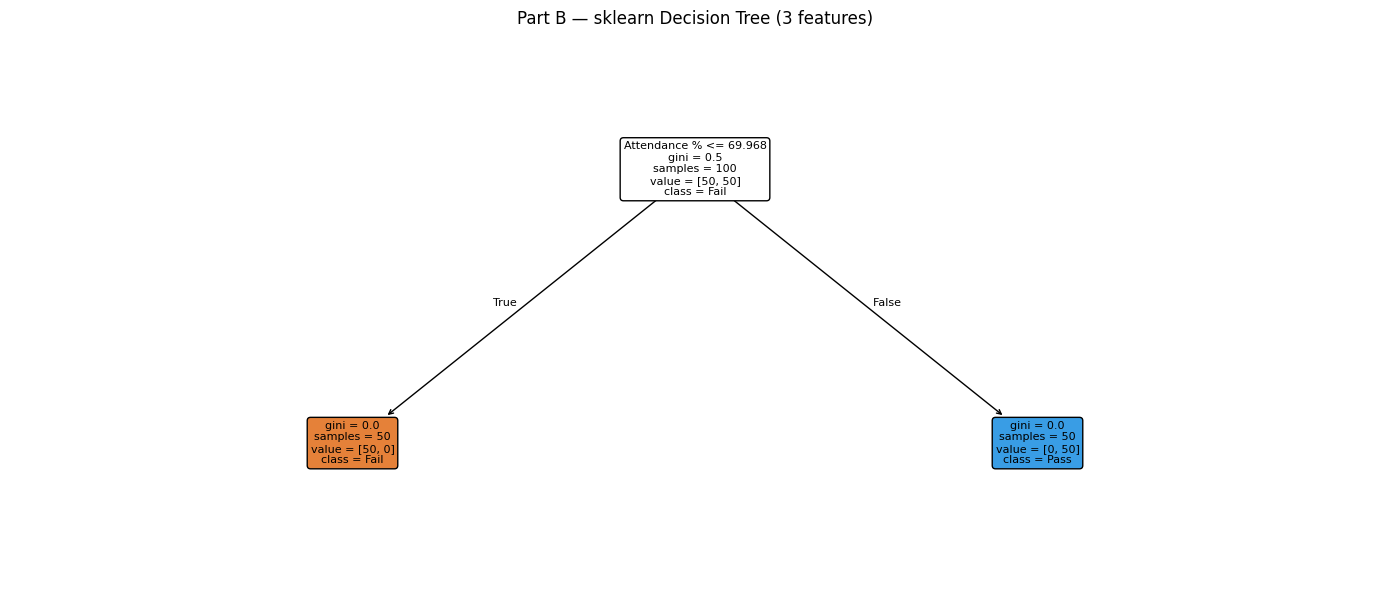

In [22]:
# Visualize the sklearn tree (feature names = Study hours, Attendance %, Assignment %)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plot_tree(
    skl_ex,
    feature_names=feat_labels_ex,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Part B — sklearn Decision Tree (3 features)')
plt.tight_layout()
plt.show()

---
## Exercise 3 — Part C (20%): Iris Dataset

**Goal:** Load the **Iris** dataset (from `sklearn.datasets`), optionally split into train/test, train a decision tree (NumPy or sklearn), visualize the decision boundary (e.g. using first 2 features), and report accuracy. Use the commented hints in the code blocks below.

### Part C — Step 1: Load Iris and (optional) train/test split

Load the Iris dataset, get features `X_iris` and labels `y_iris`. Optionally shuffle and split into 80% train / 20% test for a more realistic accuracy estimate.

In [23]:
# ========== Part C — Load Iris dataset ==========

from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

# Train/test split using shuffled indices
np.random.seed(42)

n_iris = len(y_iris)
idx_iris = np.random.permutation(n_iris)

split = int(0.8 * n_iris)

train_idx = idx_iris[:split]
test_idx = idx_iris[split:]

X_train_iris, X_test_iris = X_iris[train_idx], X_iris[test_idx]
y_train_iris, y_test_iris = y_iris[train_idx], y_iris[test_idx]

print("Iris shape:", X_iris.shape, "| Classes:", np.unique(y_iris))
print("Feature names:", iris.feature_names)
print("Train size:", len(y_train_iris), "| Test size:", len(y_test_iris))

Iris shape: (150, 4) | Classes: [0 1 2]
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Train size: 120 | Test size: 30


### Part C — Step 2: Train decision tree and visualize

Train a decision tree (sklearn) on the Iris data. For a 2D decision boundary plot, use only the first two features (e.g. sepal length, sepal width). Report training (and test) accuracy. Use `print_tree` or `plot_tree` to inspect the tree.

Iris Decision Tree Training Accuracy: 1.0000
Iris Decision Tree Test Accuracy: 0.9333


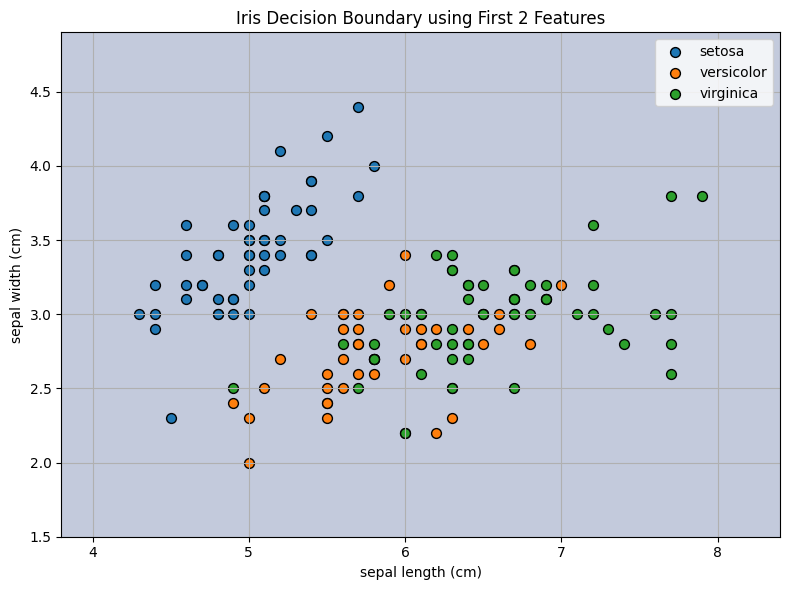

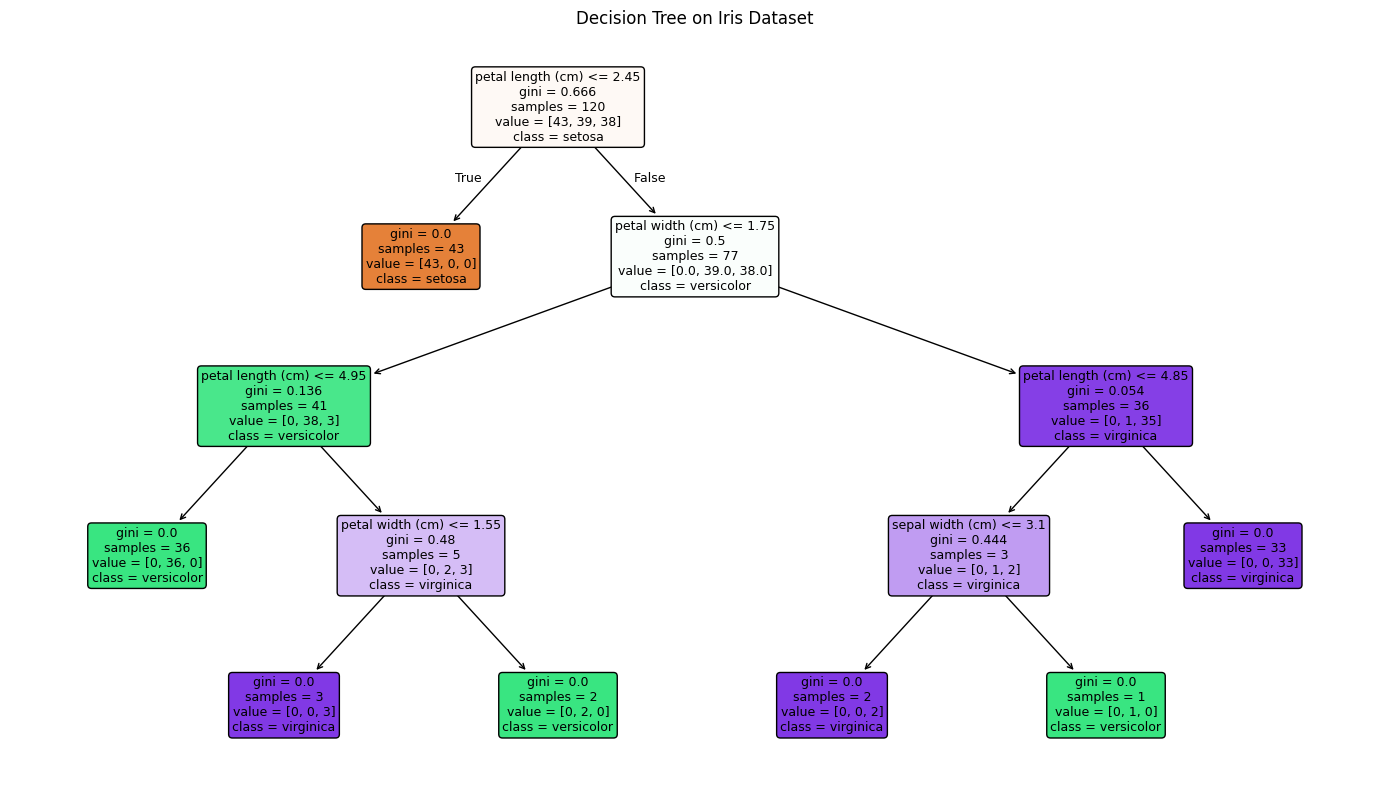

In [24]:
# ========== Part C — Train decision tree on Iris and visualize — use hints ==========
# HINT 1: Train on full Iris (or X_train_iris).
# ========== Part C — Train decision tree on Iris and visualize ==========

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# 1. Train decision tree on 4 Iris features
tree_iris = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tree_iris.fit(X_train_iris, y_train_iris)

# 2. Accuracy
train_acc = tree_iris.score(X_train_iris, y_train_iris)
test_acc = tree_iris.score(X_test_iris, y_test_iris)

print(f"Iris Decision Tree Training Accuracy: {train_acc:.4f}")
print(f"Iris Decision Tree Test Accuracy: {test_acc:.4f}")

# 3. Decision boundary using first 2 features
X_plot = X_iris[:, :2]

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Grid must still have 4 features because tree was trained on 4 features
median_features = np.median(X_iris, axis=0)
grid = np.tile(median_features, (xx.ravel().shape[0], 1))

grid[:, 0] = xx.ravel()
grid[:, 1] = yy.ravel()

Z = tree_iris.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

for cls in np.unique(y_iris):
    mask = y_iris == cls
    plt.scatter(
        X_iris[mask, 0],
        X_iris[mask, 1],
        label=iris.target_names[cls],
        edgecolors="black",
        s=50
    )

plt.title("Iris Decision Boundary using First 2 Features")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Visualize the decision tree
plt.figure(figsize=(14, 8))
plot_tree(
    tree_iris,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree on Iris Dataset")
plt.tight_layout()
plt.show()

# Short analysis:
# The decision tree learns simple if-else rules to separate the three Iris species.
# Training accuracy is usually high because the tree can split the feature space into class-specific regions.
# Test accuracy is a better estimate of real performance because it checks the model on unseen samples.
# The 2D decision boundary uses only the first two features for visualization, while the actual model was trained on all four features.

---
**Exercises summary:**  
- **Part A (50%):** 3-feature pass/fail data generation, pairwise visualization, and NumPy decision tree (using the class from Section 3) with pairwise decision boundaries and prediction.  
- **Part B (30%):** Same 3-feature problem with scikit-learn: train, plot boundaries, and predict.  
- **Part C (20%):** Iris dataset: load, train decision tree, visualize (e.g. 2D boundary), report accuracy.